In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [38]:
class GreetState(BaseModel):
    message: str = ""

In [22]:
graph = StateGraph(GreetState)

In [11]:
### Nodes - Python Functions

In [31]:
def Greet(state:GreetState):
    state.message = f"{state.message} ! All Good ! "
    return state



def upperCase(state:GreetState):
    state.message = state.message.upper()
    return state

In [23]:
graph.add_node("greet", Greet)

In [32]:
graph.add_node("upper_case", upperCase)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [33]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper_case")
graph.add_edge("greet", "upper_case")
graph.add_edge("upper_case", END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [34]:
finalGraph = graph.compile()

In [35]:
res = finalGraph.invoke({"message":"I love LangGraph !"})

In [36]:
res

{'message': 'I LOVE LANGGRAPH ! ! ALL GOOD ! '}

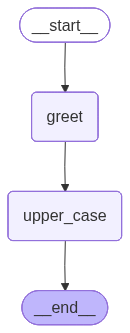

In [37]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())